# Run Comparison
Compare probing results across hypothesis generation methods and stock vs finetuned models.

**Setup:** add entries to `RUNS` in the config cell, then run all cells.

In [1]:
import sys
from pathlib import Path

_root = Path('.').resolve()
if not (_root / 'probing').exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

RUNS = [
    dict(label="Stock · template",             method="template",            model="roberta-large-mnli"),
    dict(label="Stock · multi-template",        method="multi-template",      model="roberta-large-mnli"),
    dict(label="Stock · type-aware-templates",  method="type-aware-templates",model="roberta-large-mnli"),
    # dict(label="Stock · llm-openai",           method="llm-openai",          model="roberta-large-mnli"),

    # Finetuned variants — uncomment once available:
    # dict(label="Finetuned · template",            method="template",            model="roberta-large-mnli-spr-bin"),
    # dict(label="Finetuned · multi-template",      method="multi-template",      model="roberta-large-mnli-spr-bin"),
    dict(label="Finetuned · type-aware-templates",method="type-aware-templates",model="roberta-large-mnli-spr-bin"),
    # dict(label="Finetuned · llm-openai",          method="llm-openai",          model="roberta-large-mnli-spr-bin"),
]

SPLIT = "dev"
LABEL_THRESHOLD = 4

for run in RUNS:
    run["path"] = _root / "artifacts" / "probing" / run["method"] / run["model"] / "predictions.jsonl"
    status = "✓" if run["path"].exists() else "✗ MISSING"
    print(f"{status}  {run['label']:<45s}  {run['path']}")

✓  Stock · template                               /home/tubinex/Documents/Projects/Semantik/artifacts/probing/template/roberta-large-mnli/predictions.jsonl
✓  Stock · multi-template                         /home/tubinex/Documents/Projects/Semantik/artifacts/probing/multi-template/roberta-large-mnli/predictions.jsonl
✓  Stock · type-aware-templates                   /home/tubinex/Documents/Projects/Semantik/artifacts/probing/type-aware-templates/roberta-large-mnli/predictions.jsonl
✓  Finetuned · type-aware-templates               /home/tubinex/Documents/Projects/Semantik/artifacts/probing/type-aware-templates/roberta-large-mnli-spr-bin/predictions.jsonl


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from interpretability.eval import precision, recall, accuracy, kappa

dfs = {}
for run in RUNS:
    if not run["path"].exists():
        print(f"Skipping (missing): {run['label']}")
        continue
    records = []
    with open(run["path"]) as f:
        for line in f:
            r = json.loads(line)
            if SPLIT is None or r.get("split") == SPLIT:
                records.append(r)
    df = pd.DataFrame(records)
    df["gold"] = (df["label"].astype(int) >= LABEL_THRESHOLD).astype(int)
    df["pred"] = df["pred_bool"].astype(int)
    dfs[run["label"]] = df
    print(f"Loaded {len(df):>7,} rows  [{run['label']}]")

RUN_LABELS = list(dfs.keys())
COLORS = plt.cm.tab10(np.linspace(0, 0.9, max(len(RUN_LABELS), 2)))

def _metrics(df):
    g, p = df["gold"].values, df["pred"].values
    prec = precision(g, p)
    rec  = recall(g, p)
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(accuracy=accuracy(g, p), precision=prec, recall=rec, f1=f1,
                kappa=kappa(g, p), n=len(df))

def _per_property(df):
    rows = {}
    for prop, grp in df.groupby("property"):
        rows[prop] = _metrics(grp)
    return pd.DataFrame(rows).T

overall   = {label: _metrics(df)        for label, df in dfs.items()}
per_prop  = {label: _per_property(df)   for label, df in dfs.items()}
properties = sorted(next(iter(per_prop.values())).index.tolist())

Loaded  19,278 rows  [Stock · template]
Loaded  19,278 rows  [Stock · multi-template]
Loaded  19,278 rows  [Stock · type-aware-templates]
Loaded  19,278 rows  [Finetuned · type-aware-templates]


In [3]:
rows = []
for label in RUN_LABELS:
    m = overall[label]
    rows.append({"Run": label, "N": f"{m['n']:,}",
                 "Accuracy": f"{m['accuracy']:.4f}", "Precision": f"{m['precision']:.4f}",
                 "Recall": f"{m['recall']:.4f}", "F1": f"{m['f1']:.4f}",
                 "Kappa": f"{m['kappa']:.4f}"})

tbl = pd.DataFrame(rows).set_index("Run")

def _highlight_max(s):
    try:
        vals = s.astype(float)
        return ["font-weight: bold; color: #27ae60" if v == vals.max() else "" for v in vals]
    except Exception:
        return [""] * len(s)

display(tbl.style
        .apply(_highlight_max, subset=["Accuracy", "Precision", "Recall", "F1", "Kappa"])
        .set_caption(f"Overall metrics — split: {SPLIT or 'all'}"))

,N,Accuracy,Precision,Recall,F1,Kappa
Run,,,,,,
Stock · template,"19,278",0.5645,0.3957,0.7761,0.5242,0.1944
Stock · multi-template,"19,278",0.5460,0.3814,0.7541,0.5066,0.1630
Stock · type-aware-templates,"19,278",0.5763,0.4066,0.8077,0.5409,0.2204
Finetuned · type-aware-templates,"19,278",0.7893,0.6055,0.9134,0.7282,0.5674


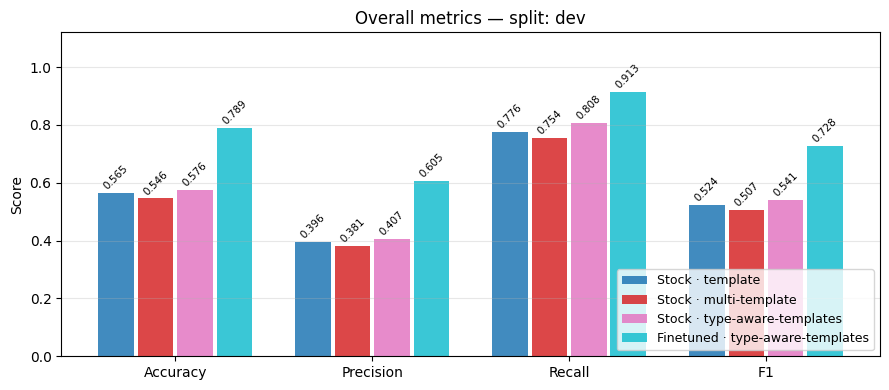

In [4]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(RUN_LABELS)

fig, ax = plt.subplots(figsize=(9, 4))
for i, label in enumerate(RUN_LABELS):
    vals = [overall[label][m] for m in metrics_to_plot]
    offset = (i - len(RUN_LABELS) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width * 0.9, label=label, color=COLORS[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7.5, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title(f"Overall metrics — split: {SPLIT or 'all'}")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

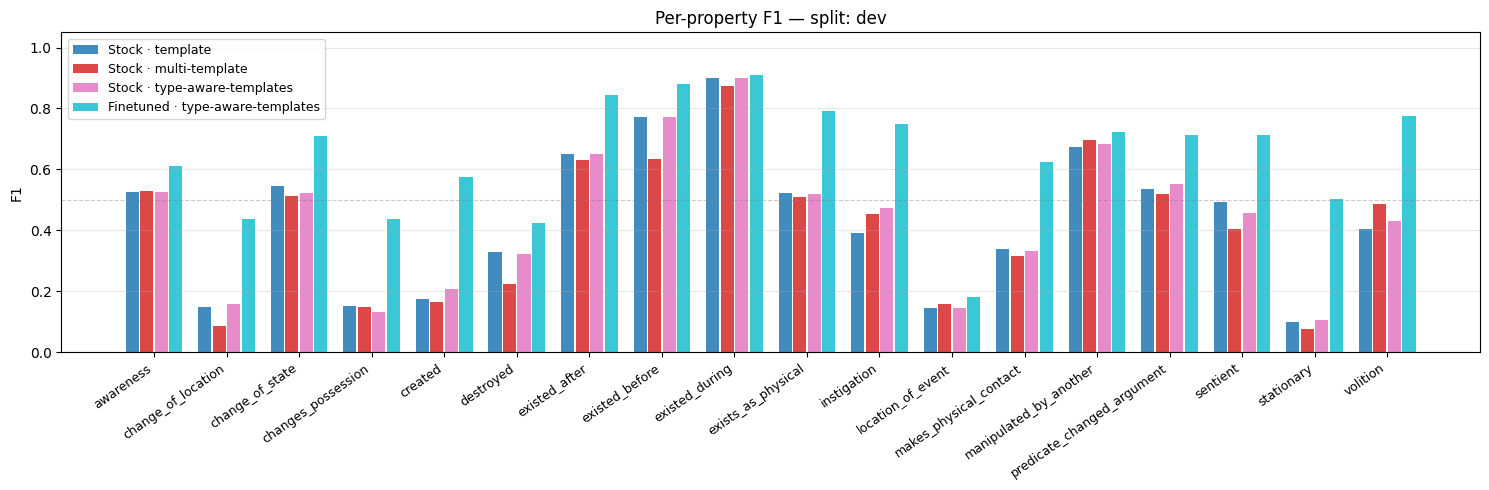

In [5]:
x = np.arange(len(properties))
width = 0.8 / len(RUN_LABELS)

fig, ax = plt.subplots(figsize=(15, 5))
for i, label in enumerate(RUN_LABELS):
    f1s = [per_prop[label].loc[p, "f1"] for p in properties]
    offset = (i - len(RUN_LABELS) / 2 + 0.5) * width
    ax.bar(x + offset, f1s, width * 0.9, label=label, color=COLORS[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(properties, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1")
ax.set_title(f"Per-property F1 — split: {SPLIT or 'all'}")
ax.legend(fontsize=9)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

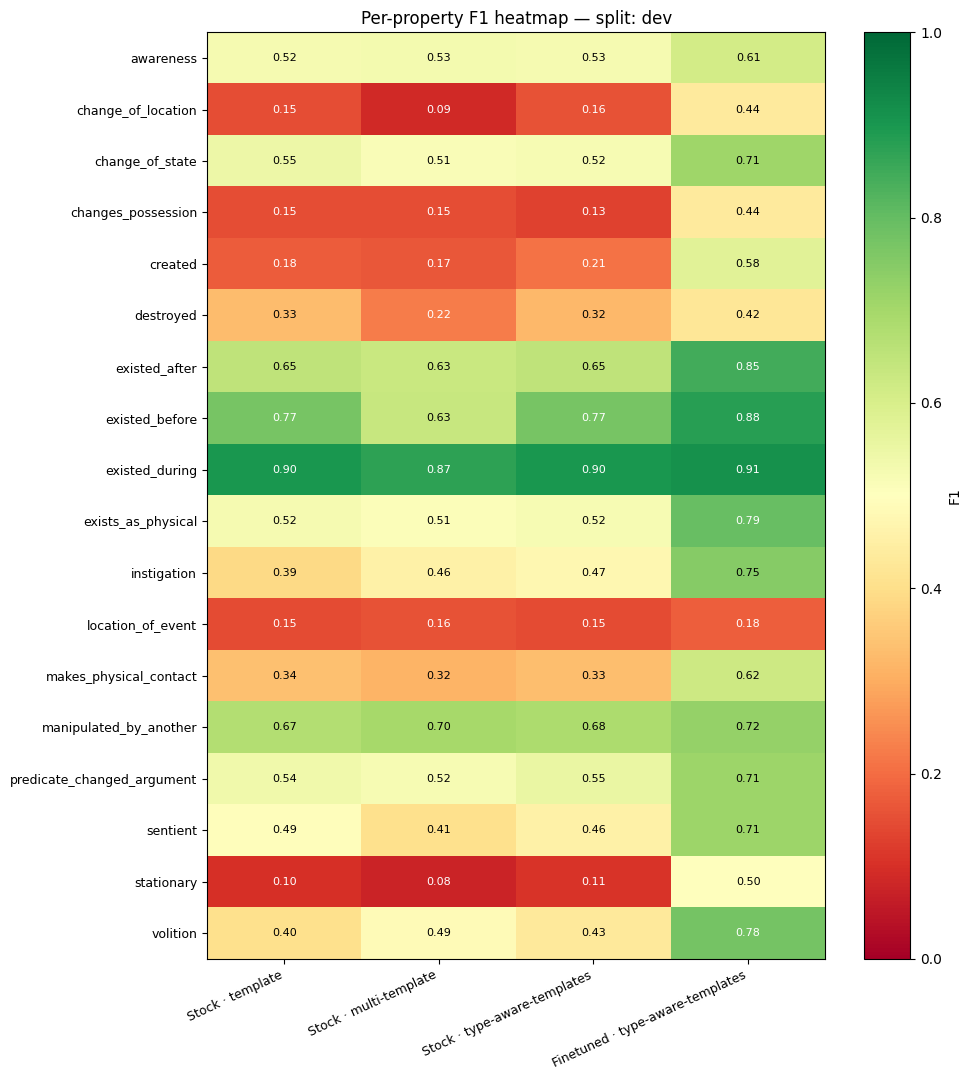

In [6]:
heatmap_data = pd.DataFrame(
    {label: [per_prop[label].loc[p, "f1"] for p in properties] for label in RUN_LABELS},
    index=properties,
)

fig, ax = plt.subplots(figsize=(max(5, len(RUN_LABELS) * 2.5), len(properties) * 0.55 + 1))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(RUN_LABELS)))
ax.set_xticklabels(RUN_LABELS, rotation=25, ha="right", fontsize=9)
ax.set_yticks(range(len(properties)))
ax.set_yticklabels(properties, fontsize=9)
for r in range(len(properties)):
    for c in range(len(RUN_LABELS)):
        v = heatmap_data.iloc[r, c]
        ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                fontsize=8, color="black" if 0.25 < v < 0.75 else "white")
plt.colorbar(im, ax=ax, label="F1")
ax.set_title(f"Per-property F1 heatmap — split: {SPLIT or 'all'}")
plt.tight_layout()
plt.show()

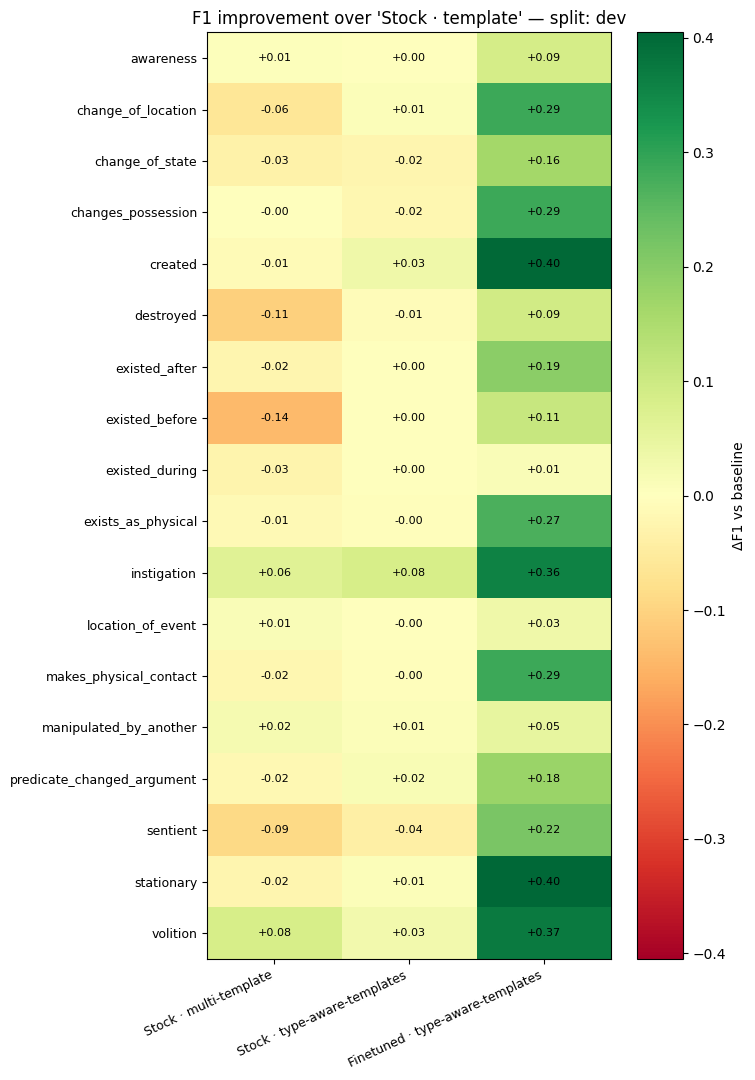

Overall F1 delta vs 'Stock · template':
  Stock · multi-template: -0.0176  (0.5242 → 0.5066)
  Stock · type-aware-templates: +0.0167  (0.5242 → 0.5409)
  Finetuned · type-aware-templates: +0.2040  (0.5242 → 0.7282)


In [7]:
if len(RUN_LABELS) >= 2:
    baseline_label = RUN_LABELS[0]
    compare_labels = RUN_LABELS[1:]

    delta_data = pd.DataFrame(
        {label: [per_prop[label].loc[p, "f1"] - per_prop[baseline_label].loc[p, "f1"]
                 for p in properties]
         for label in compare_labels},
        index=properties,
    )

    vabs = max(abs(delta_data.values.min()), abs(delta_data.values.max()), 0.01)
    fig, ax = plt.subplots(figsize=(max(4, len(compare_labels) * 2.5), len(properties) * 0.55 + 1))
    im = ax.imshow(delta_data.values, aspect="auto", cmap="RdYlGn", vmin=-vabs, vmax=vabs)
    ax.set_xticks(range(len(compare_labels)))
    ax.set_xticklabels(compare_labels, rotation=25, ha="right", fontsize=9)
    ax.set_yticks(range(len(properties)))
    ax.set_yticklabels(properties, fontsize=9)
    for r in range(len(properties)):
        for c in range(len(compare_labels)):
            v = delta_data.iloc[r, c]
            ax.text(c, r, f"{v:+.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, label="ΔF1 vs baseline")
    ax.set_title(f"F1 improvement over '{baseline_label}' — split: {SPLIT or 'all'}")
    plt.tight_layout()
    plt.show()

    print(f"Overall F1 delta vs '{baseline_label}':")
    base_f1 = overall[baseline_label]["f1"]
    for label in compare_labels:
        delta = overall[label]["f1"] - base_f1
        print(f"  {label}: {delta:+.4f}  ({base_f1:.4f} → {overall[label]['f1']:.4f})")
else:
    print("Add at least 2 runs to see the delta chart.")

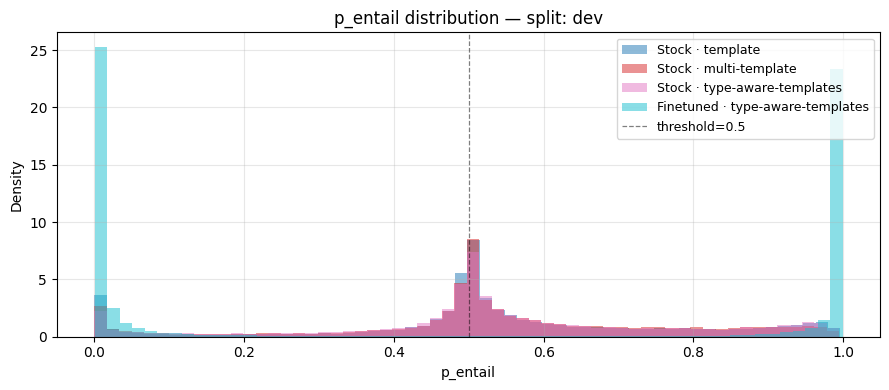

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for i, label in enumerate(RUN_LABELS):
    ax.hist(dfs[label]["p_entail"], bins=60, alpha=0.5,
            color=COLORS[i], label=label, density=True)
ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.9, label="threshold=0.5")
ax.set_xlabel("p_entail")
ax.set_ylabel("Density")
ax.set_title(f"p_entail distribution — split: {SPLIT or 'all'}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2679890/1974938023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=gold_labels, patch_artist=True, widths=0.5,
/tmp/ipykernel_2679890/1974938023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=gold_labels, patch_artist=True, widths=0.5,
/tmp/ipykernel_2679890/1974938023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=gold_labels, patch_artist=True, widths=0.5,
/tmp/ipykernel_2679890/1974938023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' s

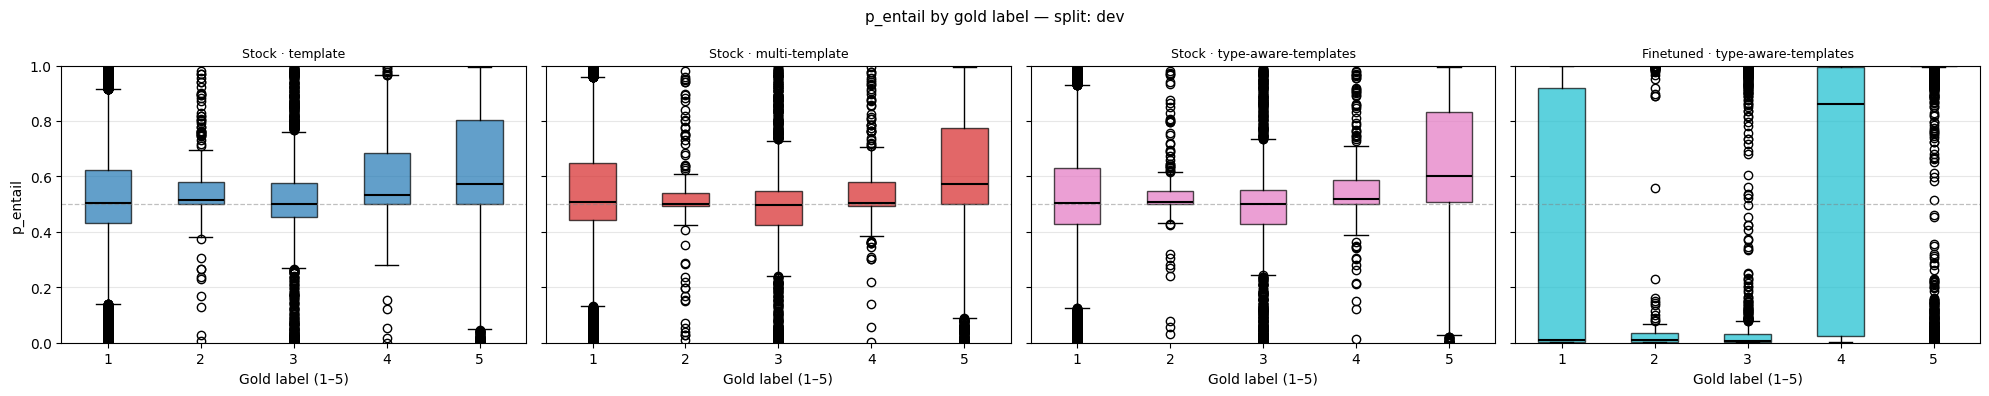

In [9]:
gold_labels = [1, 2, 3, 4, 5]
n_runs = len(RUN_LABELS)
fig, axes = plt.subplots(1, n_runs, figsize=(5 * n_runs, 4), sharey=True)
if n_runs == 1:
    axes = [axes]

for ax, (label, color) in zip(axes, zip(RUN_LABELS, COLORS)):
    df = dfs[label]
    groups = [df[df["label"].astype(int) == gl]["p_entail"].values for gl in gold_labels]
    bp = ax.boxplot(groups, labels=gold_labels, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=0.9)
    ax.set_xlabel("Gold label (1–5)")
    ax.set_ylabel("p_entail" if ax is axes[0] else "")
    ax.set_title(label, fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"p_entail by gold label — split: {SPLIT or 'all'}", fontsize=11)
plt.tight_layout()
plt.show()

## Type Analysis (type-aware-templates only)

For runs using type-aware templates, classify each argument's semantic type and check whether the hypothesis used a type-specific template or fell back to the generic one.

In [10]:
from hypothesis.type_aware_templates import TEMPLATES, classify_type, batch_classify

TAT_LABELS = [lbl for lbl in RUN_LABELS if "type-aware" in lbl.lower()]

if TAT_LABELS:
    ref_df = dfs[TAT_LABELS[0]]
    all_args = ref_df["arg"].tolist()
    print(f"Pre-classifying {len(set(all_args)):,} unique args …")
    batch_classify(all_args)

    for lbl in TAT_LABELS:
        df = dfs[lbl]
        df["arg_type"] = df["arg"].apply(classify_type)
        df["used_generic"] = df.apply(
            lambda r: TEMPLATES.get(r["arg_type"], {}).get(r["property"]) is None,
            axis=1,
        )
    print("Done. Types assigned:", sorted(dfs[TAT_LABELS[0]]["arg_type"].unique()))
else:
    print("No type-aware-templates runs loaded — skipping type analysis.")

Pre-classifying 908 unique args …


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Classifying argument types: 100%|██████████| 908/908 [01:05<00:00, 13.91arg/s]


Done. Types assigned: ['abstract_concept', 'human', 'location', 'organization', 'physical_object', 'quantity_or_measure']


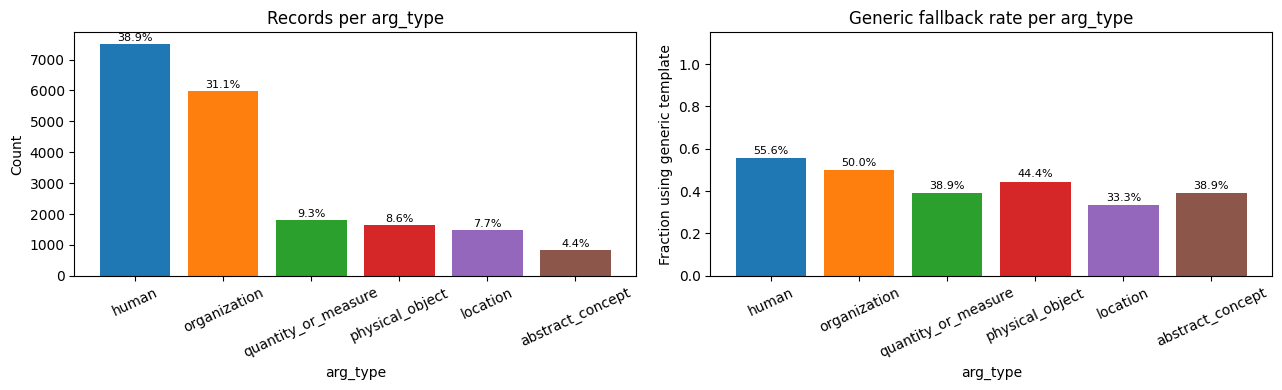

Total records : 19,278
Generic fallback: 9,424 (48.9%)
Type-specific   : 9,854 (51.1%)


In [11]:
if TAT_LABELS:
    ref_df = dfs[TAT_LABELS[0]]
    type_counts = ref_df.groupby("arg_type").size().sort_values(ascending=False)
    n_total = len(ref_df)
    fallback_rate = ref_df.groupby("arg_type")["used_generic"].mean().reindex(type_counts.index)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].bar(type_counts.index, type_counts.values, color=plt.cm.tab10.colors[:len(type_counts)])
    axes[0].set_title("Records per arg_type")
    axes[0].set_xlabel("arg_type")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=25)
    for i, (t, v) in enumerate(type_counts.items()):
        axes[0].text(i, v + n_total * 0.005, f"{v/n_total:.1%}", ha="center", fontsize=8)

    bars = axes[1].bar(fallback_rate.index, fallback_rate.values, color=plt.cm.tab10.colors[:len(fallback_rate)])
    axes[1].set_title("Generic fallback rate per arg_type")
    axes[1].set_xlabel("arg_type")
    axes[1].set_ylabel("Fraction using generic template")
    axes[1].set_ylim(0, 1.15)
    axes[1].tick_params(axis="x", rotation=25)
    for bar, v in zip(bars, fallback_rate.values):
        axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.1%}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    total_fallback = ref_df["used_generic"].sum()
    print(f"Total records : {n_total:,}")
    print(f"Generic fallback: {total_fallback:,} ({total_fallback/n_total:.1%})")
    print(f"Type-specific   : {n_total - total_fallback:,} ({(n_total - total_fallback)/n_total:.1%})")

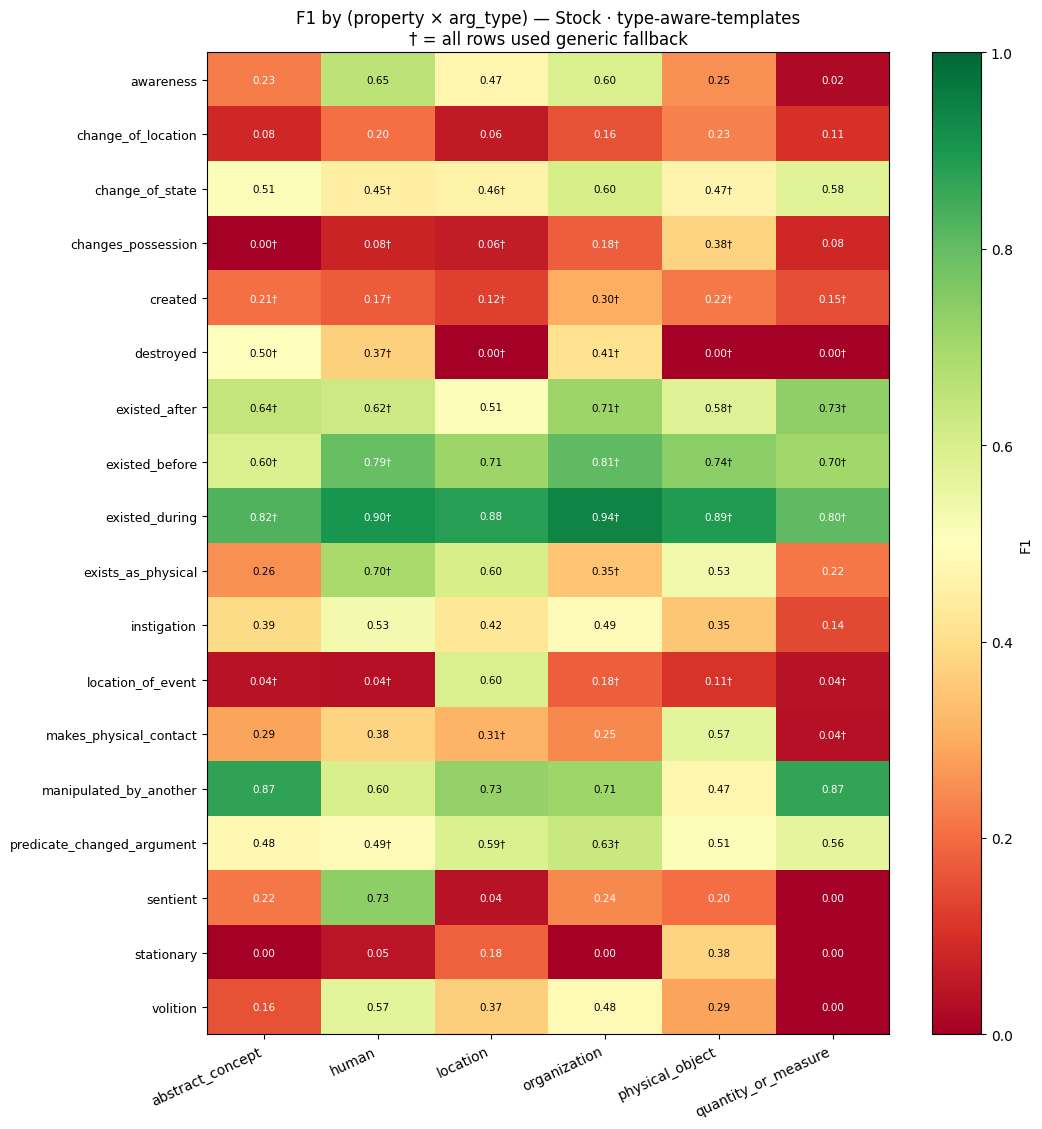

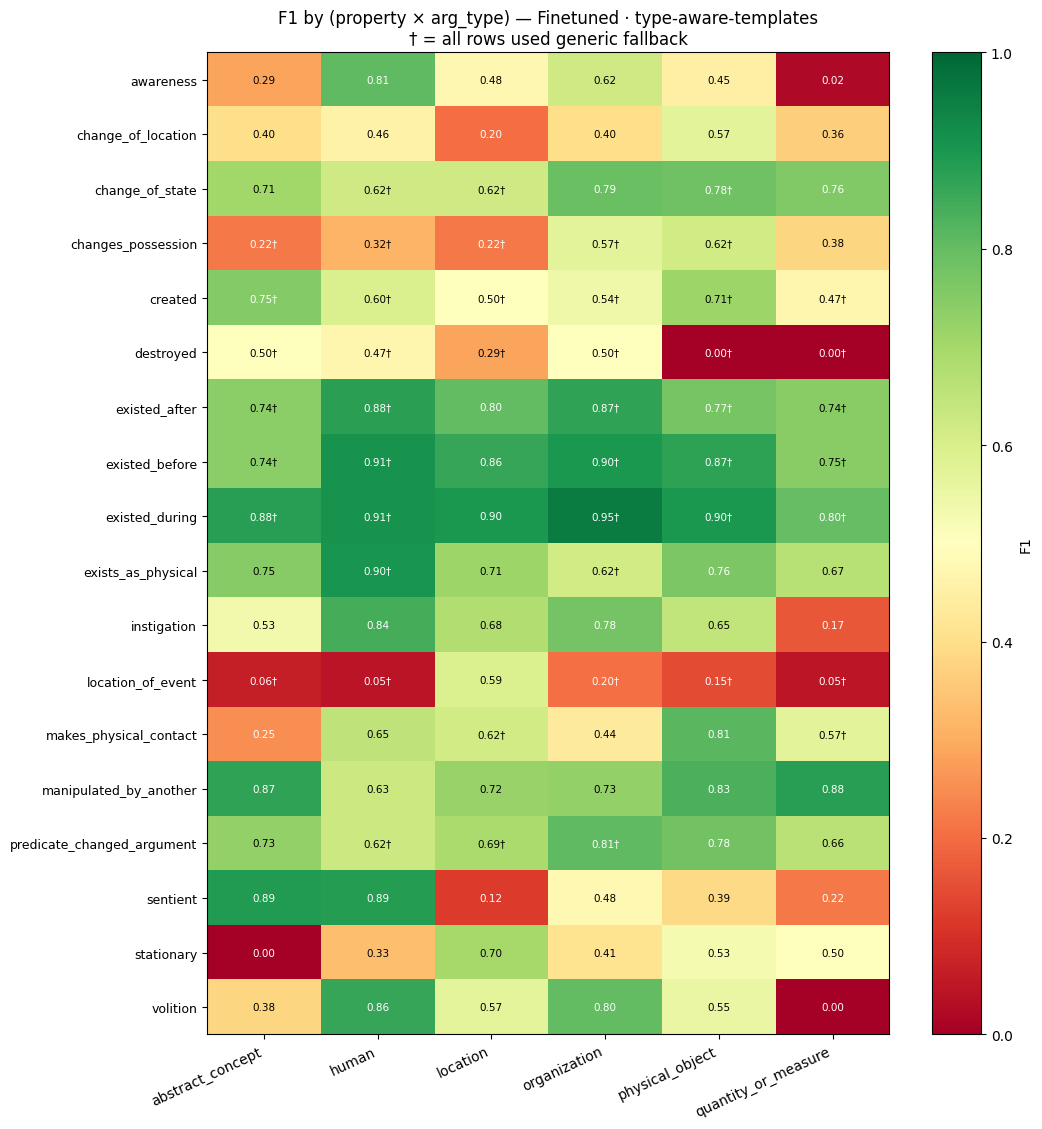

In [12]:
if TAT_LABELS:
    for lbl in TAT_LABELS:
        df = dfs[lbl]
        types_present = sorted(df["arg_type"].unique())

        heat_vals = {}
        for t in types_present:
            sub = df[df["arg_type"] == t]
            heat_vals[t] = {
                p: _metrics(sub[sub["property"] == p])["f1"]
                for p in properties
                if len(sub[sub["property"] == p]) > 0
            }

        heat = pd.DataFrame(heat_vals, index=properties).fillna(float("nan"))

        fig, ax = plt.subplots(figsize=(max(5, len(types_present) * 1.8), len(properties) * 0.55 + 1.5))
        im = ax.imshow(heat.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
        ax.set_xticks(range(len(types_present)))
        ax.set_xticklabels(types_present, rotation=25, ha="right")
        ax.set_yticks(range(len(properties)))
        ax.set_yticklabels(properties, fontsize=9)

        for r, prop in enumerate(properties):
            for c, t in enumerate(types_present):
                v = heat.loc[prop, t]
                if pd.isna(v):
                    continue
                type_rows = df[(df["arg_type"] == t) & (df["property"] == prop)]
                # † marks cells where ALL rows fell back to generic
                marker = "†" if type_rows["used_generic"].all() else ""
                ax.text(
                    c, r, f"{v:.2f}{marker}",
                    ha="center", va="center", fontsize=7.5,
                    color="black" if 0.25 < v < 0.75 else "white",
                )

        plt.colorbar(im, ax=ax, label="F1")
        ax.set_title(f"F1 by (property × arg_type) — {lbl}\n† = all rows used generic fallback")
        plt.tight_layout()
        plt.show()

## Per-property Threshold Calibration

Sweep decision thresholds per property on the **dev** split to maximise F1, then compare calibrated vs default (0.5) performance.

In [13]:
CALIB_SPLIT = "dev"
SWEEP = np.linspace(0.05, 0.95, 181)

def _best_threshold(series_p, series_gold):
    """Return (best_threshold, best_f1) over SWEEP."""
    g = series_gold.values
    best_f1, best_t = 0.0, 0.5
    for t in SWEEP:
        pred = (series_p.values >= t).astype(int)
        tp = int(((pred == 1) & (g == 1)).sum())
        fp = int(((pred == 1) & (g == 0)).sum())
        fn = int(((pred == 0) & (g == 1)).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

calib_dfs = {}
for run in RUNS:
    if not run["path"].exists():
        continue
    records = [json.loads(l) for l in open(run["path"]) if json.loads(l).get("split") == CALIB_SPLIT]
    df = pd.DataFrame(records)
    df["gold"] = (df["label"].astype(int) >= LABEL_THRESHOLD).astype(int)
    df["pred"] = df["pred_bool"].astype(int)
    calib_dfs[run["label"]] = df

thresholds = {}
for lbl, df in calib_dfs.items():
    thresholds[lbl] = {}
    for prop in properties:
        sub = df[df["property"] == prop]
        if len(sub) == 0:
            thresholds[lbl][prop] = (0.5, 0.0)
            continue
        thresholds[lbl][prop] = _best_threshold(sub["p_entail"], sub["gold"])

print("Optimal thresholds (threshold → best dev F1):")
for lbl in RUN_LABELS:
    t_vals = [thresholds[lbl][p][0] for p in properties]
    f1_vals = [thresholds[lbl][p][1] for p in properties]
    print(f"\n  {lbl}")
    for p, t, f1 in sorted(zip(properties, t_vals, f1_vals), key=lambda x: x[1]):
        marker = " ←" if abs(t - 0.5) > 0.15 else ""
        print(f"    {p:<35s}  t={t:.2f}  F1={f1:.3f}{marker}")

Optimal thresholds (threshold → best dev F1):

  Stock · template
    instigation                          t=0.05  F1=0.515 ←
    manipulated_by_another               t=0.05  F1=0.723 ←
    existed_after                        t=0.06  F1=0.811 ←
    stationary                           t=0.20  F1=0.126 ←
    existed_before                       t=0.20  F1=0.791 ←
    volition                             t=0.22  F1=0.503 ←
    existed_during                       t=0.27  F1=0.904 ←
    predicate_changed_argument           t=0.29  F1=0.545 ←
    awareness                            t=0.30  F1=0.534 ←
    sentient                             t=0.49  F1=0.498
    change_of_state                      t=0.51  F1=0.554
    makes_physical_contact               t=0.55  F1=0.345
    exists_as_physical                   t=0.65  F1=0.583 ←
    change_of_location                   t=0.70  F1=0.225 ←
    destroyed                            t=0.80  F1=0.364 ←
    created                             

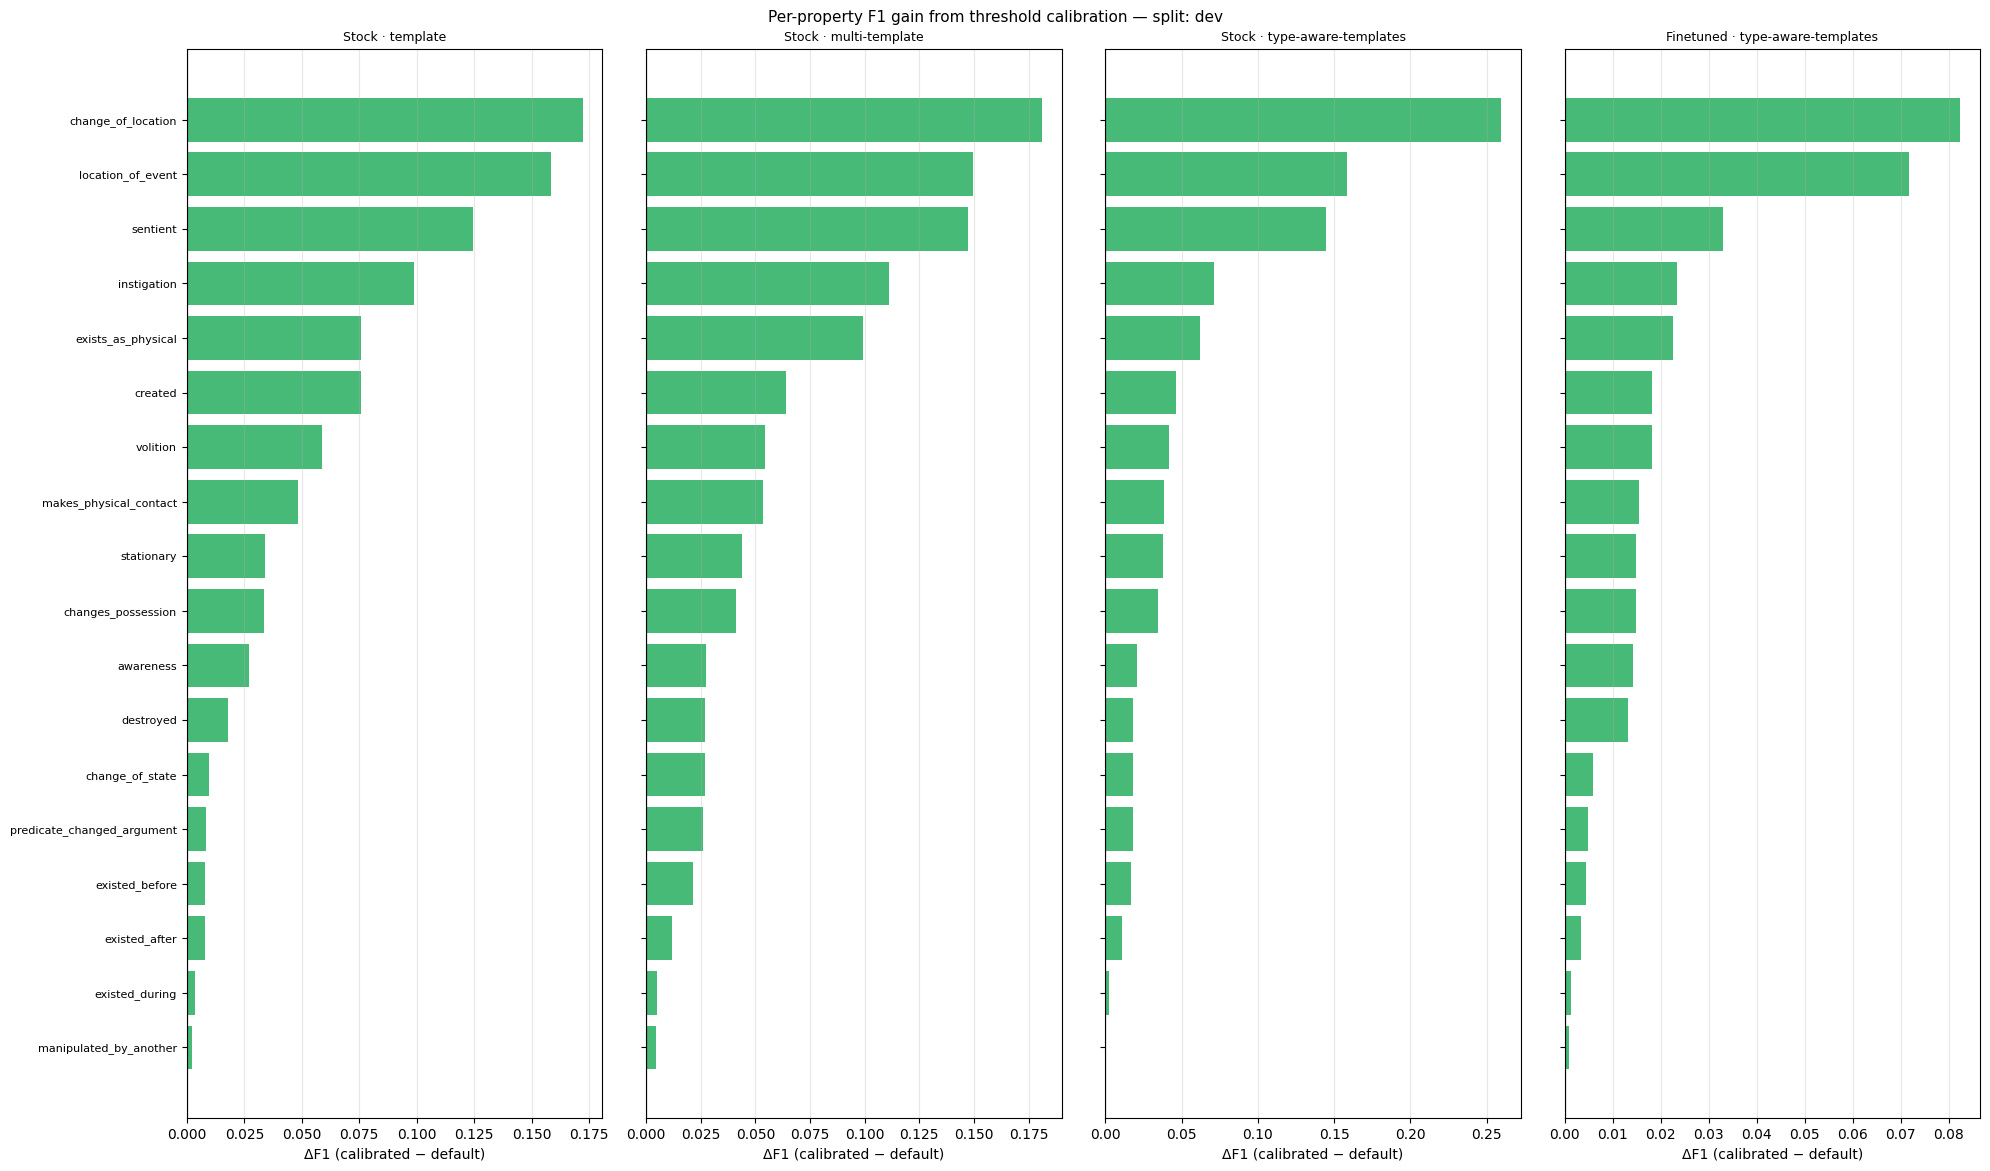

Run                                            Default F1  Calibrated F1       Δ
--------------------------------------------------------------------------------
Stock · template                                   0.5242         0.6245  +0.1004
Stock · multi-template                             0.5066         0.6025  +0.0959
Stock · type-aware-templates                       0.5409         0.6312  +0.0903
Finetuned · type-aware-templates                   0.7282         0.7548  +0.0266


In [14]:
def _calibrated_metrics(df, thresholds_for_run):
    rows = {}
    for prop in properties:
        sub = df[df["property"] == prop]
        if len(sub) == 0:
            continue
        t = thresholds_for_run[prop][0]
        pred = (sub["p_entail"].values >= t).astype(int)
        gold = sub["gold"].values
        tp = int(((pred == 1) & (gold == 1)).sum())
        fp = int(((pred == 1) & (gold == 0)).sum())
        fn = int(((pred == 0) & (gold == 1)).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        rows[prop] = f1
    return rows

fig, axes = plt.subplots(1, len(RUN_LABELS), figsize=(5 * len(RUN_LABELS), len(properties) * 0.55 + 2),
                         sharey=True)
if len(RUN_LABELS) == 1:
    axes = [axes]

for ax, lbl in zip(axes, RUN_LABELS):
    default_f1  = {p: per_prop[lbl].loc[p, "f1"] for p in properties}
    calibrated_f1 = _calibrated_metrics(calib_dfs[lbl], thresholds[lbl])

    props_sorted = sorted(properties, key=lambda p: calibrated_f1.get(p, 0) - default_f1.get(p, 0))
    deltas = [calibrated_f1.get(p, 0) - default_f1.get(p, 0) for p in props_sorted]
    colors = ["#27ae60" if d >= 0 else "#e74c3c" for d in deltas]

    ax.barh(range(len(props_sorted)), deltas, color=colors, alpha=0.85)
    ax.set_yticks(range(len(props_sorted)))
    ax.set_yticklabels(props_sorted, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("ΔF1 (calibrated − default)")
    ax.set_title(lbl, fontsize=9)
    ax.grid(axis="x", alpha=0.3)

fig.suptitle(f"Per-property F1 gain from threshold calibration — split: {CALIB_SPLIT}", fontsize=11)
plt.tight_layout()
plt.show()

print(f"{'Run':<45s}  {'Default F1':>10s}  {'Calibrated F1':>13s}  {'Δ':>6s}")
print("-" * 80)
for lbl in RUN_LABELS:
    df = calib_dfs[lbl]
    def_f1 = _metrics(df)["f1"]
    all_pred, all_gold = [], []
    for prop in properties:
        sub = df[df["property"] == prop]
        if len(sub) == 0:
            continue
        t = thresholds[lbl][prop][0]
        all_pred.extend((sub["p_entail"].values >= t).astype(int).tolist())
        all_gold.extend(sub["gold"].values.tolist())
    g, p = np.array(all_gold), np.array(all_pred)
    tp = int(((p == 1) & (g == 1)).sum())
    fp = int(((p == 1) & (g == 0)).sum())
    fn = int(((p == 0) & (g == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    cal_f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{lbl:<45s}  {def_f1:>10.4f}  {cal_f1:>13.4f}  {cal_f1 - def_f1:>+6.4f}")